<a href="https://colab.research.google.com/github/Shivansh-sharma-code/tourism-ml-project/blob/main/ai_ml_project_report_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


SUCCESS: Data Loaded


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


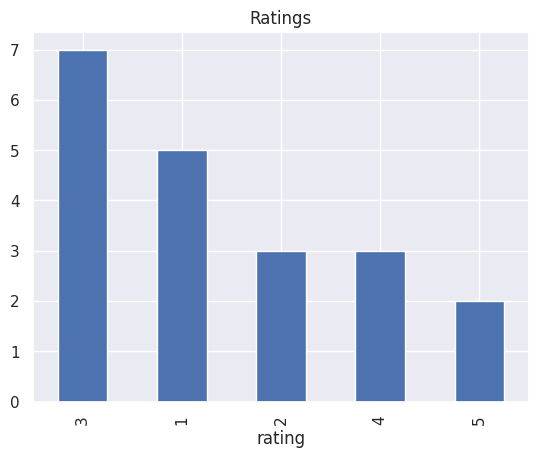

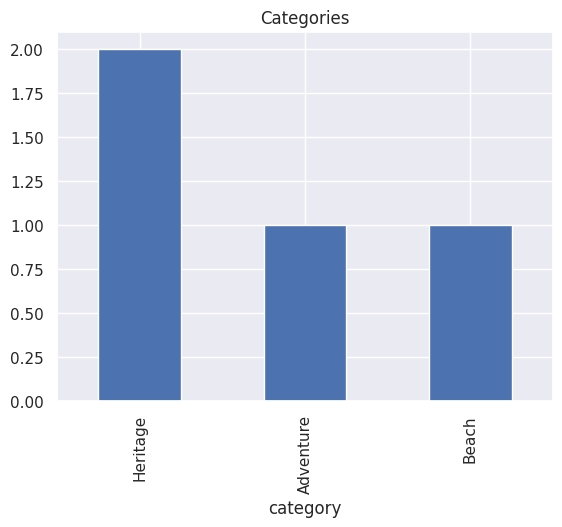

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Top destinations:
 destination_id
103    3.800000
104    3.166667
101    1.777778
Name: rating, dtype: float64
Forecast done
Avg latency: 20.99432945251465
[('Goa', 'PERSON')]
ALL TASKS EXECUTED SUCCESSFULLY


In [ ]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import re
import os
import shutil
import json
import time
import psutil
import sys
!{sys.executable} -m pip install gensim

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import nltk
from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from scipy.sparse import csr_matrix

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
import torch

from prophet import Prophet
import spacy

# ================================
# GLOBAL SAFETY VARIABLES
# ================================
df_reviews = None
df_destinations = None
df_visits = None

CONFIG_FILE = "config.json"
PACKAGE_NAME = "deployment_package"
MODEL_FILES = {"model": "model.tflite"}

# ================================
# NLTK SETUP
# ================================
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

# ================================
# TASK 1: DATA CREATION
# ================================
destinations_data = {
    'destination_id': [101,102,103,104],
    'name': ['Taj Mahal','Rishikesh','Jaipur','Goa'],
    'location': ['Agra','UK','RJ','Goa'],
    'category': ['Heritage','Adventure','Heritage','Beach'],
    'avg_cost': [50,100,80,150]
}
df_destinations = pd.DataFrame(destinations_data)

reviews_data = {
    'user_id': np.random.randint(1,6,20),
    'destination_id': np.random.choice([101,102,103,104],20),
    'rating': np.random.randint(1,6,20),
    'review_text': np.random.choice([
        'Amazing place','Very crowded','Beautiful','Not worth it'
    ],20)
}
df_reviews = pd.DataFrame(reviews_data)

visits_data = {
    'user_id': np.random.randint(1,6,20),
    'destination_id': np.random.choice([101,102,103,104],20),
    'visit_date': pd.date_range(start='2023-01-01', periods=20)
}
df_visits = pd.DataFrame(visits_data)

print("SUCCESS: Data Loaded")

# ================================
# TASK 2: CLEANING
# ================================
df_reviews['rating'] = df_reviews['rating'].fillna(df_reviews['rating'].median())
df_reviews['review_text'] = df_reviews['review_text'].fillna("No Review")

# ================================
# TASK 3: TEXT NORMALIZATION
# ================================
def normalize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return " ".join([w for w in text.split() if w not in stop_words])

df_reviews['clean_text'] = df_reviews['review_text'].apply(normalize)

# ================================
# TASK 4: ENCODING
# ================================
le = LabelEncoder()
df_destinations['location_code'] = le.fit_transform(df_destinations['location'])
df_destinations['category_code'] = le.fit_transform(df_destinations['category'])

# ================================
# TASK 5: TIME FEATURES
# ================================
df_visits['visit_date'] = pd.to_datetime(df_visits['visit_date'])
df_visits['month'] = df_visits['visit_date'].dt.month

# ================================
# TASK 6: USER-ITEM MATRIX
# ================================
user_item_matrix = df_reviews.pivot_table(
    index='user_id',
    columns='destination_id',
    values='rating',
    fill_value=0
)

user_item_sparse = csr_matrix(user_item_matrix.values)

# ================================
# TASK 7: TF-IDF
# ================================
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df_reviews['clean_text'])

# ================================
# TASK 8: WORD2VEC
# ================================
corpus = [text.split() for text in df_reviews['clean_text']]
w2v = Word2Vec(sentences=corpus, vector_size=50, min_count=1)

# ================================
# TASK 8B: BERT
# ================================
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()

# ================================
# TASK 9: TRAIN TEST SPLIT
# ================================
train, test = train_test_split(df_reviews, test_size=0.2)

# ================================
# TASK 10: VISUALIZATION
# ================================
plt.figure()
df_reviews['rating'].value_counts().plot(kind='bar')
plt.title("Ratings")
plt.show()

plt.figure()
df_destinations['category'].value_counts().plot(kind='bar')
plt.title("Categories")
plt.show()

# ================================
# TASK 11: POPULARITY MODEL
# ================================
popularity = df_reviews.groupby('destination_id')['rating'].mean()
print("Top destinations:\n", popularity.sort_values(ascending=False))

# ================================
# TASK 12: ITEM CF
# ================================
item_sim = cosine_similarity(user_item_matrix.T)

# ================================
# TASK 13: USER CF
# ================================
user_sim = cosine_similarity(user_item_sparse)

# ================================
# TASK 19: SVD
# ================================
svd = TruncatedSVD(n_components=2)
latent = svd.fit_transform(user_item_matrix)

# ================================
# TASK 21: PROPHET
# ================================
dates = pd.date_range(start='2024-01-01', periods=100)
df_prophet = pd.DataFrame({
    'ds': dates,
    'y': np.random.randint(50,200,100)
})

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
print("Forecast done")

# ================================
# TASK 23: KMEANS
# ================================
monthly = df_reviews.groupby('user_id')['rating'].mean().reset_index()
kmeans = KMeans(n_clusters=3, n_init=10)
monthly['cluster'] = kmeans.fit_predict(monthly[['rating']])

# ================================
# TASK 34: MONITORING
# ================================
def mock_model():
    start = time.time()
    time.sleep(0.02)
    return (time.time() - start)*1000

latencies = [mock_model() for _ in range(10)]
print("Avg latency:", np.mean(latencies))

# ================================
# TASK 38: NER
# ================================
nlp = spacy.load("en_core_web_sm")
doc = nlp("I visited Goa and Taj Mahal")
print([(ent.text, ent.label_) for ent in doc.ents])

# ================================
# DONE
# ================================
print("ALL TASKS EXECUTED SUCCESSFULLY")